# Reconcile overview

Loads every `reactor.yaml` under `reactors/`, reconciles each one, and renders a single variable-by-reactor table plus the plasma cross-sections.

**Reactor header** is red when reconciliation failed, normal otherwise.

**Variable cells** (a variable is *used* when it enters the reactor's active relation graph):

- <span style='background-color:#c6efce;color:#006100;padding:1px 5px'>green</span> &mdash; input, used, value unchanged after reconcile (`value`).
- <span style='background-color:#ffeb9c;color:#9c6500;padding:1px 5px'>yellow</span> &mdash; input, used, moved within tolerance (`input (value)`).
- <span style='background-color:#ffc7ce;color:#9c0006;padding:1px 5px'>red</span> &mdash; input, used, moved beyond tolerance (`input → value`, the culprit input is **bold**).
- transparent + grey value &mdash; variable not used.
- transparent + normal value &mdash; value computed by reconcile.

Diagnostics (warnings, errors, failed relations) are printed inline while each reactor is solved.

In [1]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Locate the project root and import the package.
root = Path.cwd().resolve()
while root != root.parent and not (root / "src" / "fusdb").is_dir():
    root = root.parent
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))

from fusdb import Reactor
from fusdb.relations.geometry.plasma_geometry import sauter_cross_section_points


def fmt(x):
    """Compact number / profile formatting for table and legend cells."""
    if x is None:
        return ""
    a = np.asarray(x, dtype=float)
    if a.ndim == 0 or a.size == 1:
        v = float(a.ravel()[0])
        if v == 0:
            return "0"
        if abs(v) >= 1e4 or abs(v) < 1e-3:
            return f"{v:.3e}"
        return f"{v:.4g}"
    return f"prof[{a.size}] mean={np.nanmean(a):.3g}"


def pick(system, name):
    """Return a variable's reconciled value, falling back to its input."""
    var = system.variables_by_name.get(name)
    if var is None:
        return None
    return var.value if var.value is not None else var.input_value


reactor_files = sorted((root / "reactors").rglob("reactor.yaml"))
print(f"Found {len(reactor_files)} reactor(s) under {root / 'reactors'}")

Found 7 reactor(s) under /home/alessmor/Scrivania/fusdb/reactors


In [2]:
# Reconcile every reactor, printing warnings and errors as each one is solved.
records = []
for path in reactor_files:
    reactor = Reactor.from_yaml(path)
    system = reactor.to_relation_system()
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        try:
            result = system.run("reconcile")
        except Exception as exc:
            result = {"success": False, "termination": f"crashed: {exc!r}", "errors": [repr(exc)], "warnings": []}
    elapsed = time.perf_counter() - started

    success = bool(result.get("success", False))
    relation_status = result.get("relation_status", {})
    failed = [n for n, s in relation_status.items() if isinstance(s, dict) and s.get("enforced", True) and not s.get("verified", False)]

    records.append({
        "name": reactor.name,
        "system": system,
        "active": set(system.active_variable_names),
        "success": success,
    })

    print(f"{'OK  ' if success else 'FAIL'} {reactor.name} in {elapsed:.1f}s | termination={result.get('termination', '?')}")
    for err in result.get("errors", []):
        print(f"      error: {err}")
    for msg in result.get("warnings", []):
        print(f"      warning: {msg}")
    for w in caught:
        print(f"      {w.category.__name__}: {w.message}")
    if failed:
        print(f"      failed relations: {', '.join(failed)}")

FAIL ARC 2015 in 5.0s | termination=The maximum number of function evaluations is exceeded.
      failed relations: Total fusion power, Toroidal beta, Normalized beta, Default electron temperature profile from average temperature, Default ion temperature profile from average temperature
FAIL ARC V3A in 0.5s | termination=initialization failed
      error: Uninitialized required free variables: P_charged, P_fus_DD, P_fus_DDn, P_fus_DDn_He3, P_fus_DDn_n, P_fus_DDp, P_fus_DDp_T, P_fus_DDp_p, P_fus_DHe3, P_fus_DHe3_alpha, P_fus_DHe3_p, P_fus_DT, P_fus_DT_alpha, P_fus_DT_n, P_fus_TT, P_neutron, Rr_DDn, Rr_DDp, Rr_DHe3, Rr_DT, Rr_He3He3, Rr_THe3, Rr_THe3_D, Rr_THe3_np, Rr_TT, n_D, n_He3, n_He4, n_T, n_e, n_i, n_imp. These variables were not supplied and were not generated by active relations.
FAIL EU-DEMO 2022 in 10.3s | termination=The maximum number of function evaluations is exceeded.
      failed relations: Elongation 95%, L-H transition threshold power, Total fusion power, Greenwald den

In [3]:
# Variable-by-reactor table: variables as rows, reactors as columns.
# Rows are every variable that is an input or is used in at least one reactor.
var_names = set()
for rec in records:
    var_names |= rec["active"]
    for name, var in rec["system"].variables_by_name.items():
        if var.input_value is not None:
            var_names.add(name)
var_names = sorted(var_names)

html = ["<table style='border-collapse:collapse;font-size:0.8em'>"]
html.append("<tr><th style='text-align:left;padding:2px 8px'>variable</th>")
for rec in records:
    color = "#c00000" if not rec["success"] else "#1EFF00"
    html.append(f"<th style='padding:2px 8px;color:{color}'>{rec['name']}</th>")
html.append("</tr>")

for name in var_names:
    html.append(f"<tr><td style='text-align:left;padding:2px 8px;font-weight:bold'>{name}</td>")
    for rec in records:
        var = rec["system"].variables_by_name.get(name)
        background = ""
        color = "#000000"
        text = ""
        if var is not None:
            has_input = var.input_value is not None
            used = name in rec["active"]
            inp = var.input_value
            val = var.value
            if has_input and used and val is not None:
                ai = np.asarray(inp, dtype=float)
                av = np.asarray(val, dtype=float)
                try:
                    exact = bool(np.array_equal(ai, av))
                    scale = max(float(np.max(np.abs(ai))), float(np.max(np.abs(av))), 1e-300)
                    tol = max(float(var.abs_tol or 0.0), float(var.rel_tol or 0.0) * scale)
                    within = bool(np.all(np.abs(av - ai) <= tol))
                except Exception:
                    exact, within = False, False
                if exact:
                    background, color, text = "#c6efce", "#006100", fmt(val)
                elif within:
                    background, color, text = "#ffeb9c", "#9c6500", f"{fmt(inp)} ({fmt(val)})"
                else:
                    background, color, text = "#ffc7ce", "#9c0006", f"<b>{fmt(inp)}</b> &rarr; {fmt(val)}"
            elif has_input and not used:
                color, text = "#6E6E6E", fmt(inp)
            elif (not has_input) and used and val is not None:
                color, text = "#FFFFFF", fmt(val)
            elif has_input and used and val is None:
                color, text = "#606060", fmt(inp)
        style = f"padding:2px 8px;color:{color}"
        if background:
            style += f";background-color:{background}"
        html.append(f"<td style='{style}'>{text}</td>")
    html.append("</tr>")
html.append("</table>")
display(HTML("".join(html)))

variable,ARC 2015,ARC V3A,EU-DEMO 2022,Hammir 2024,INFINITY TWO 2025,Stellaris 2025 - Point A,STEP 2024 EB-CC
A,2.92,,3.1,,10,9.8,1.8
A_p,232.4,257,1583,,,327,361.5
B0,9.2 → 9.672,11.4,5.86 → 4.971,,,9 → 7.932,3.2 → 2.563
B_max,23,,,,,,12
G89,0.14,,,,,,
H89,2.8,,,,,,
H98_y2,1.8,,0.98 (0.9813),,,,1.03 → 0.9922
I_p,7.800e+06 (7.800e+06),1.200e+07,1.775e+07 → 1.802e+07,,,1.603e+09,2.270e+07 → 2.675e+06
L_p,11.21,,29.5,,,,17.21
P_LH,,,1.208e+08 (1.208e+08),,,,1.803e+07


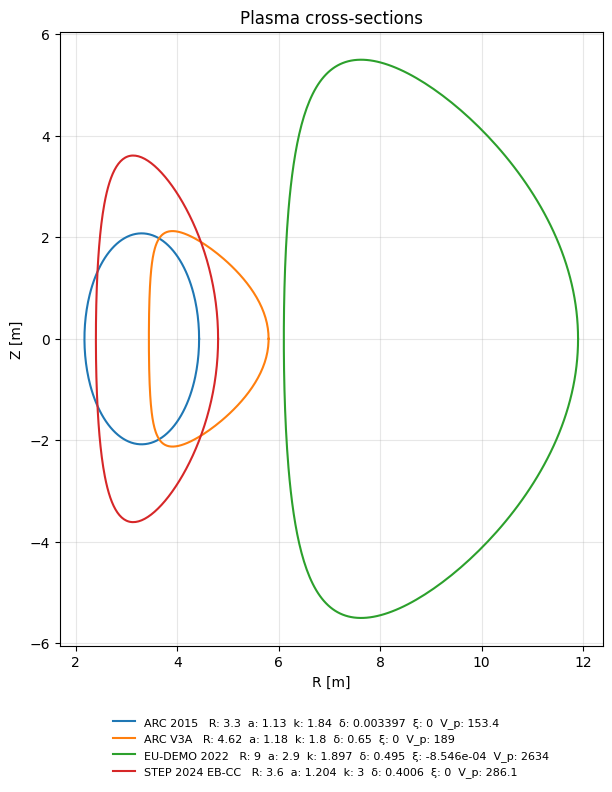

In [4]:
# Plasma cross-sections, with reactor geometry summarised in the legend below.
fig, ax = plt.subplots(figsize=(7, 8))
for rec in records:
    system = rec["system"]
    R = pick(system, "R")
    a = pick(system, "a")
    kappa = pick(system, "kappa")
    delta = pick(system, "delta")
    xi = pick(system, "squareness") or 0.0
    V_p = pick(system, "V_p")
    if None in (R, a, kappa, delta):
        continue
    r_pts, z_pts = sauter_cross_section_points(float(R), float(a), kappa=float(kappa), delta=float(delta), squareness=float(xi), n=256)
    vp_text = fmt(V_p) if V_p is not None else "—"
    label = f"{rec['name']}   R: {fmt(R)}  a: {fmt(a)}  k: {fmt(kappa)}  δ: {fmt(delta)}  ξ: {fmt(xi)}  V_p: {vp_text}"
    ax.plot(r_pts, z_pts, label=label)

ax.set_aspect("equal")
ax.set_xlabel("R [m]")
ax.set_ylabel("Z [m]")
ax.set_title("Plasma cross-sections")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), fontsize=8, frameon=False)
fig.tight_layout()
plt.show()